# 01 · Ingestion, data validation and exploratory analysis

**Source:** Fuel Economy Guide 2024 (EPA / DOE), sheet `24MY` — 964 combustion vehicle configurations certified for
model year 2024.

This notebook establishes the dataset the whole project relies on:

1. **Ingestion** of the published Excel file, with no manual intermediate edits.
2. **Cleaning and typing** through deterministic functions (`vehicle_emissions.data`).
3. **Data validation** with explicit contracts (`vehicle_emissions.validation`): schema, physical ranges,
   category domains and row-level physical consistency between CO₂ and fuel economy.
4. **Exploratory analysis** aimed at modeling decisions.
5. **Export** of the validated dataset to `data/processed/`.

In [1]:
try:
    import vehicle_emissions  # installed with `pip install -e .`
except ModuleNotFoundError:  # running without installing the package
    import sys
    from pathlib import Path
    sys.path.insert(0, str(Path.cwd().parent / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)
RANDOM_STATE = 42

## 1. Ingestion

In [2]:
from vehicle_emissions.data import RENAME, add_binary_features, clean_fe_guide, load_fe_guide_raw
from vehicle_emissions.paths import FE_GUIDE_PATH, PROCESSED_DIR

raw = load_fe_guide_raw()
print(f"{FE_GUIDE_PATH.name}: {raw.shape[0]} configurations × {raw.shape[1]} columns")
raw[["Mfr Name", "Carline", "Eng Displ", "# Cyl", "Trans Desc", "Drive Desc",
     "Comb FE (Guide) - Conventional Fuel", "Comb CO2 Rounded Adjusted (as shown on FE Label)"]].head()

2024_FE_Guide_DOE.xlsx: 964 configurations × 162 columns


,Mfr Name,Carline,Eng Displ,# Cyl,Trans Desc,Drive Desc,Comb FE (Guide) - Conventional Fuel,Comb CO2 Rounded Adjusted (as shown on FE Label)
0,aston martin,Valour,5.2,12,Manual,"2-Wheel Drive, Rear",14,619
1,BMW,Z4 M40i,3.0,6,Semi-Automatic,"2-Wheel Drive, Rear",26,338
2,BMW,Z4 sDrive30i,2.0,4,Semi-Automatic,"2-Wheel Drive, Rear",28,312
3,Volkswagen Group of,Chiron Super Sport,8.0,16,Automated Manual- Selectable (e.g. Automated M...,All Wheel Drive,9,979
4,General Motors,CORVETTE,6.2,8,Semi-Automatic,"2-Wheel Drive, Rear",19,472


Most of the 162 columns describe electric systems (batteries, fuel cells, PHEV) and are empty for combustion
vehicles. 26 relevant variables are selected:

In [3]:
pd.DataFrame({
    "Working name": list(RENAME.values()),
    "% empty in source": (raw[list(RENAME)].isna().mean() * 100).round(1).values,
}, index=pd.Index(list(RENAME), name="Original column"))

,Working name,% empty in source
Original column,,
Mfr Name,Mfr Name,0.0
Division,Division,0.0
Carline,Carline,0.0
Eng Displ,Eng Displ,0.0
# Cyl,# Cyl,0.0
City FE (Guide) - Conventional Fuel,City FE (Guide),0.0
Hwy FE (Guide) - Conventional Fuel,Hwy FE (Guide),0.0
Comb FE (Guide) - Conventional Fuel,Comb FE (Guide),0.0
Comb Unadj FE - Conventional Fuel,Comb Unadj FE,0.0


Empty values are semantic, not missing data: in `Guzzler?` they mean *not subject to the tax*, and in `Descriptor`
that the manufacturer added no description. Both are turned into 0/1 flags.

## 2. Cleaning and typing

| Variable | Transformation |
|---|---|
| `Guzzler?` | `'G'` → 1, empty → 0 |
| `Gas Guzzler Exempt` | `'T'` (truck under the 1975 NHTSA definition, exempt) → 1, `'N'` → 0 |
| `Descriptor` | `Hybrid` (full hybrid) and `Mild Hybrid` are extracted |
| `Y/N` flags | → 1 / 0 |
| `Model Family` | division + carline without drivetrain suffix → group for cross-validation |

In [4]:
df = add_binary_features(clean_fe_guide(raw))
print(f"{df.shape[0]} rows × {df.shape[1]} columns · {df['Model Family'].nunique()} model families")
df.dtypes.value_counts().rename("n columns").to_frame()

964 rows × 32 columns · 596 model families


,n columns
int64,12
str,9
Int64,8
float64,3


## 3. Data validation

Before any modeling, the dataset must pass a set of contracts. If any of them fails, `validate_fe_guide` raises
`DataValidationError` and the pipeline stops: an explicit error is preferable to a model trained on corrupted data.
The same contracts run in continuous integration (`tests/test_validation.py`).

In [5]:
from vehicle_emissions.validation import co2_relative_error, validate_fe_guide

report = validate_fe_guide(df)
report

,Check,OK,Detail
0,Schema: required columns,True,16 columns present
1,No nulls in modeling variables,True,0 nulls
2,"Physical range Eng Displ ∈ [0.5, 9.0]",True,"min=1.2, max=8, out of range=0"
3,"Physical range # Cyl ∈ [2, 16]",True,"min=3, max=16, out of range=0"
4,"Physical range # Gears ∈ [1, 12]",True,"min=1, max=10, out of range=0"
5,"Physical range Comb FE (Guide) ∈ [5, 150]",True,"min=9, max=57, out of range=0"
6,"Physical range Comb Unadj FE ∈ [5, 200]",True,"min=11.2434, max=80.4727, out of range=0"
7,"Physical range Comb CO2 ∈ [50, 1500]",True,"min=155, max=979, out of range=0"
8,"Binary flags ∈ {0, 1}",True,"['Guzzler?', 'Gas Guzzler Exempt', 'Hybrid']"
9,Category domain (drivetrain),True,5 known categories


### 3.1 Why CO₂–fuel economy consistency is the key contract

CO₂ per mile is fuel burned per mile times its carbon content:
**CO₂ [g/mi] ≈ k / FE [mpg]**, with k = 8,887 g/gallon (gasoline) and 10,180 g/gallon (diesel).
In the source data this relation holds with a median error below 0.5 %.

This check guards against a frequent, silent failure: **re-sorting one column independently** (e.g. sorting a
spreadsheet without selecting every column). Types and ranges remain valid, but each row now mixes values from
different vehicles. The failure is simulated below to show that the contract catches it:

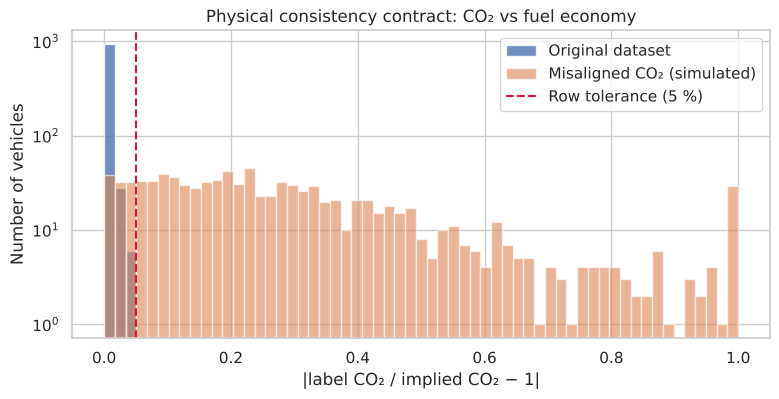

DataValidationError → CO₂ ≈ k / mpg consistency (row level) median error=23.62%, rows with error ≤ 5%: 10.6%


In [6]:
from vehicle_emissions.validation import DataValidationError

corrupted = df.copy()
corrupted["Comb CO2"] = corrupted["Comb CO2"].sample(frac=1, random_state=0).to_numpy()

fig, ax = plt.subplots(figsize=(9, 4))
bins = np.linspace(0, 1, 60)
ax.hist(co2_relative_error(df).clip(upper=1), bins=bins, alpha=0.8, label="Original dataset")
ax.hist(co2_relative_error(corrupted).clip(upper=1), bins=bins, alpha=0.6, label="Misaligned CO₂ (simulated)")
ax.axvline(0.05, color="crimson", ls="--", label="Row tolerance (5 %)")
ax.set(yscale="log", xlabel="|label CO₂ / implied CO₂ − 1|", ylabel="Number of vehicles",
       title="Physical consistency contract: CO₂ vs fuel economy")
ax.legend()
fig.savefig("../reports/figures/01_co2_consistency_contract.png", dpi=150, bbox_inches="tight")
plt.show()

try:
    validate_fe_guide(corrupted)
except DataValidationError as e:
    print("DataValidationError →", str(e).splitlines()[-1])

## 4. Exploratory analysis

### 4.1 Numeric variables

In [7]:
numeric = ["Eng Displ", "# Cyl", "# Gears", "City FE (Guide)", "Hwy FE (Guide)", "Comb FE (Guide)",
           "Comb Unadj FE", "FE Rating", "Comb CO2"]
q = df[numeric].astype(float)
pd.DataFrame({
    "mean": q.mean(), "median": q.median(), "std": q.std(),
    "P5": q.quantile(.05), "P25": q.quantile(.25), "P75": q.quantile(.75), "P95": q.quantile(.95),
    "min": q.min(), "max": q.max(), "skew": q.skew(),
}).round(2)

,mean,median,std,P5,P25,P75,P95,min,max,skew
Eng Displ,3.05,3.00,1.24,1.60,2.00,3.60,5.70,1.20,8.00,1.14
# Cyl,5.47,6.00,1.78,4.00,4.00,6.00,8.00,3.00,16.00,1.21
# Gears,7.75,8.00,1.96,1.60,7.00,9.00,10.00,1.00,10.00,-1.88
City FE (Guide),21.04,20.00,6.89,14.00,17.00,23.00,35.00,8.00,57.00,1.97
Hwy FE (Guide),26.96,26.00,6.59,18.00,22.00,31.00,38.00,11.00,58.00,0.87
Comb FE (Guide),23.26,22.00,6.63,15.15,19.00,26.00,35.00,9.00,57.00,1.50
Comb Unadj FE,31.19,29.08,9.59,20.03,24.86,35.46,48.79,11.24,80.47,1.56
FE Rating,4.57,5.00,1.28,2.15,4.00,5.00,7.00,1.00,8.00,0.10
Comb CO2,409.69,408.00,102.85,254.00,335.75,472.00,573.00,155.00,979.00,0.34


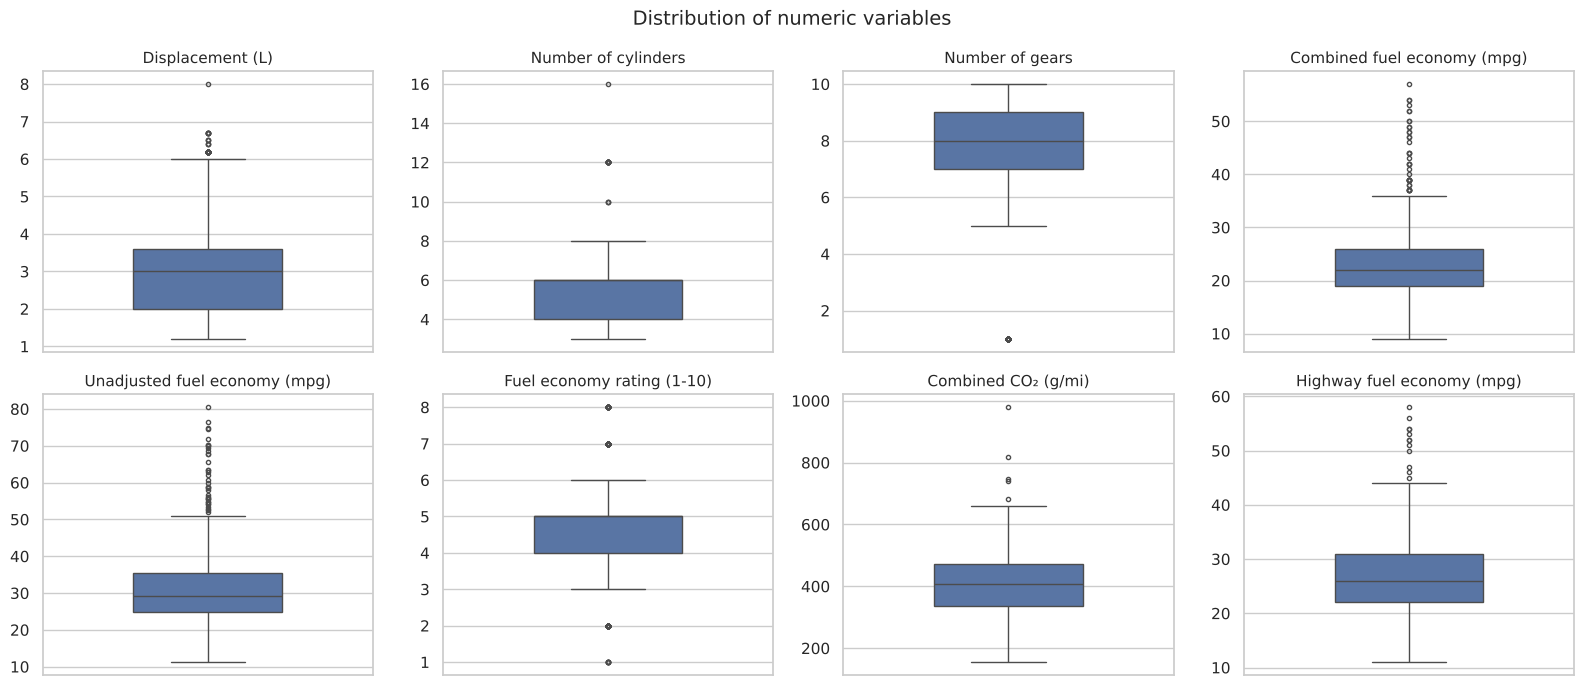

In [8]:
titles = {
    "Eng Displ": "Displacement (L)", "# Cyl": "Number of cylinders", "# Gears": "Number of gears",
    "Comb FE (Guide)": "Combined fuel economy (mpg)", "Comb Unadj FE": "Unadjusted fuel economy (mpg)",
    "FE Rating": "Fuel economy rating (1-10)", "Comb CO2": "Combined CO₂ (g/mi)", "Hwy FE (Guide)": "Highway fuel economy (mpg)",
}
fig, axs = plt.subplots(2, 4, figsize=(16, 7))
for ax, (col, t) in zip(axs.ravel(), titles.items()):
    sns.boxplot(y=q[col], ax=ax, color="#4C72B0", width=0.45, fliersize=3)
    ax.set_title(t, fontsize=11); ax.set_ylabel("")
fig.suptitle("Distribution of numeric variables", fontsize=14)
fig.tight_layout()
fig.savefig("../reports/figures/01_numeric_boxplots.png", dpi=150, bbox_inches="tight")
plt.show()

Fuel economy is right-skewed: the upper tail are **full hybrids** (up to 57 mpg) and the lower tail are 10-16 cylinder
sports cars. Both extremes are real vehicles, not data entry errors, and are kept.

### 4.2 Categorical variables

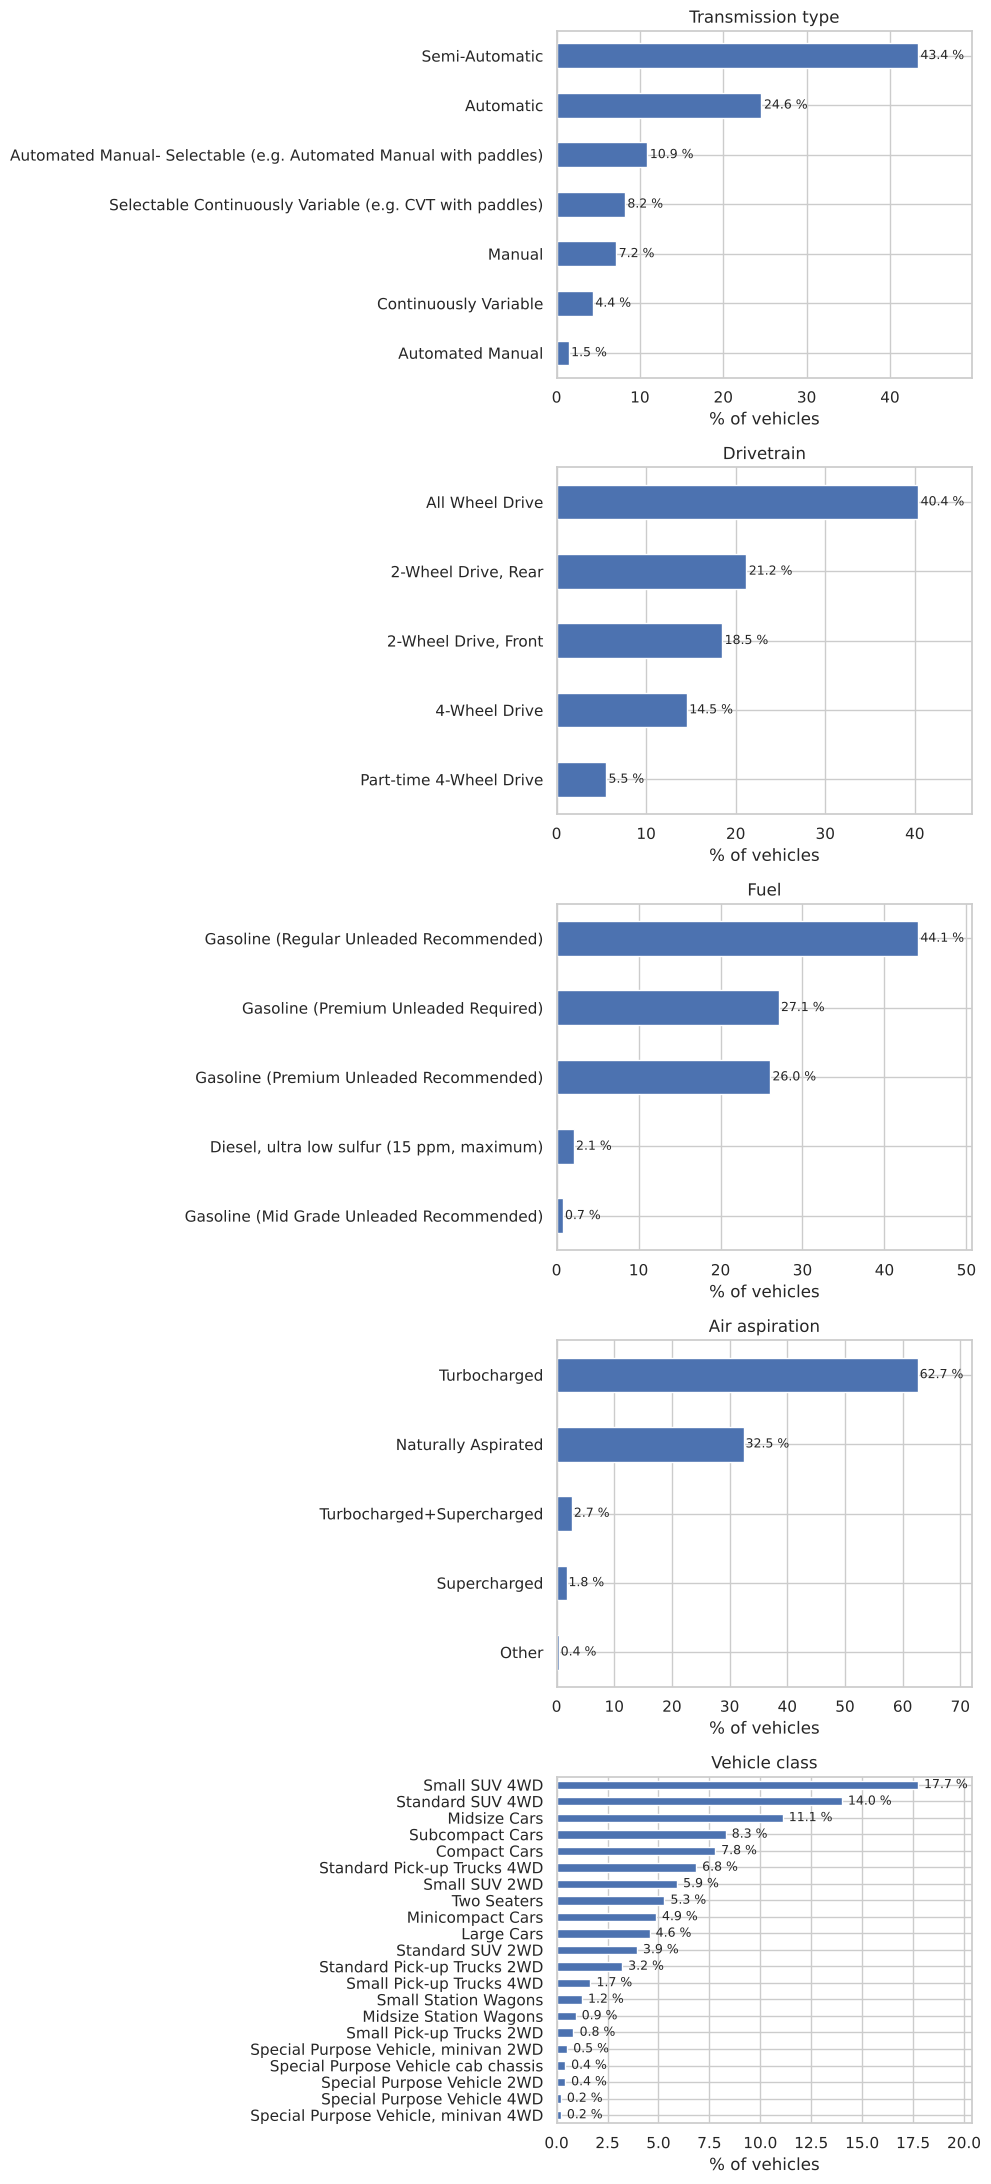

In [9]:
categorical = {
    "Trans Desc": "Transmission type", "Drive Desc": "Drivetrain", "Fuel Usage": "Fuel",
    "Air Aspiration Method Desc": "Air aspiration", "Carline Class Desc": "Vehicle class",
}
fig, axs = plt.subplots(len(categorical), 1, figsize=(10, 22))
for ax, (col, t) in zip(axs, categorical.items()):
    pct = df[col].value_counts(normalize=True).sort_values() * 100
    pct.plot.barh(ax=ax, color="#4C72B0")
    for i, v in enumerate(pct):
        ax.text(v + 0.3, i, f"{v:.1f} %", va="center", fontsize=9)
    ax.set_title(t); ax.set_xlabel("% of vehicles"); ax.set_ylabel(""); ax.set_xlim(0, pct.max() * 1.15)
fig.tight_layout()
fig.savefig("../reports/figures/01_categorical_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

In [10]:
flags = {"Hybrid": "Full hybrid", "Mild Hybrid": "Mild hybrid", "Guzzler?": "Subject to gas guzzler tax",
         "Gas Guzzler Exempt": "Exempt from gas guzzler tax", "Cyl Deact?": "Cylinder deactivation",
         "Stop/Start": "Stop/start", "Automatic": "Automatic transmission", "AWD/4WD": "All-wheel / four-wheel drive",
         "Large": "Large vehicle"}
(df[list(flags)].mean().rename(flags) * 100).round(1).to_frame("% of vehicles")

,% of vehicles
Full hybrid,6.6
Mild hybrid,14.0
Subject to gas guzzler tax,5.7
Exempt from gas guzzler tax,55.7
Cylinder deactivation,18.9
Stop/start,77.9
Automatic transmission,92.8
All-wheel / four-wheel drive,60.4
Large vehicle,48.9


Two imbalances shape the modeling: there are only **20 diesel vehicles** (2.1 %) and **55 gas guzzlers** (5.7 %).
The first limits what the model can learn about fuel type; the second calls for metrics and splits suited to
imbalanced classes in notebook 03.

### 4.3 Correlations

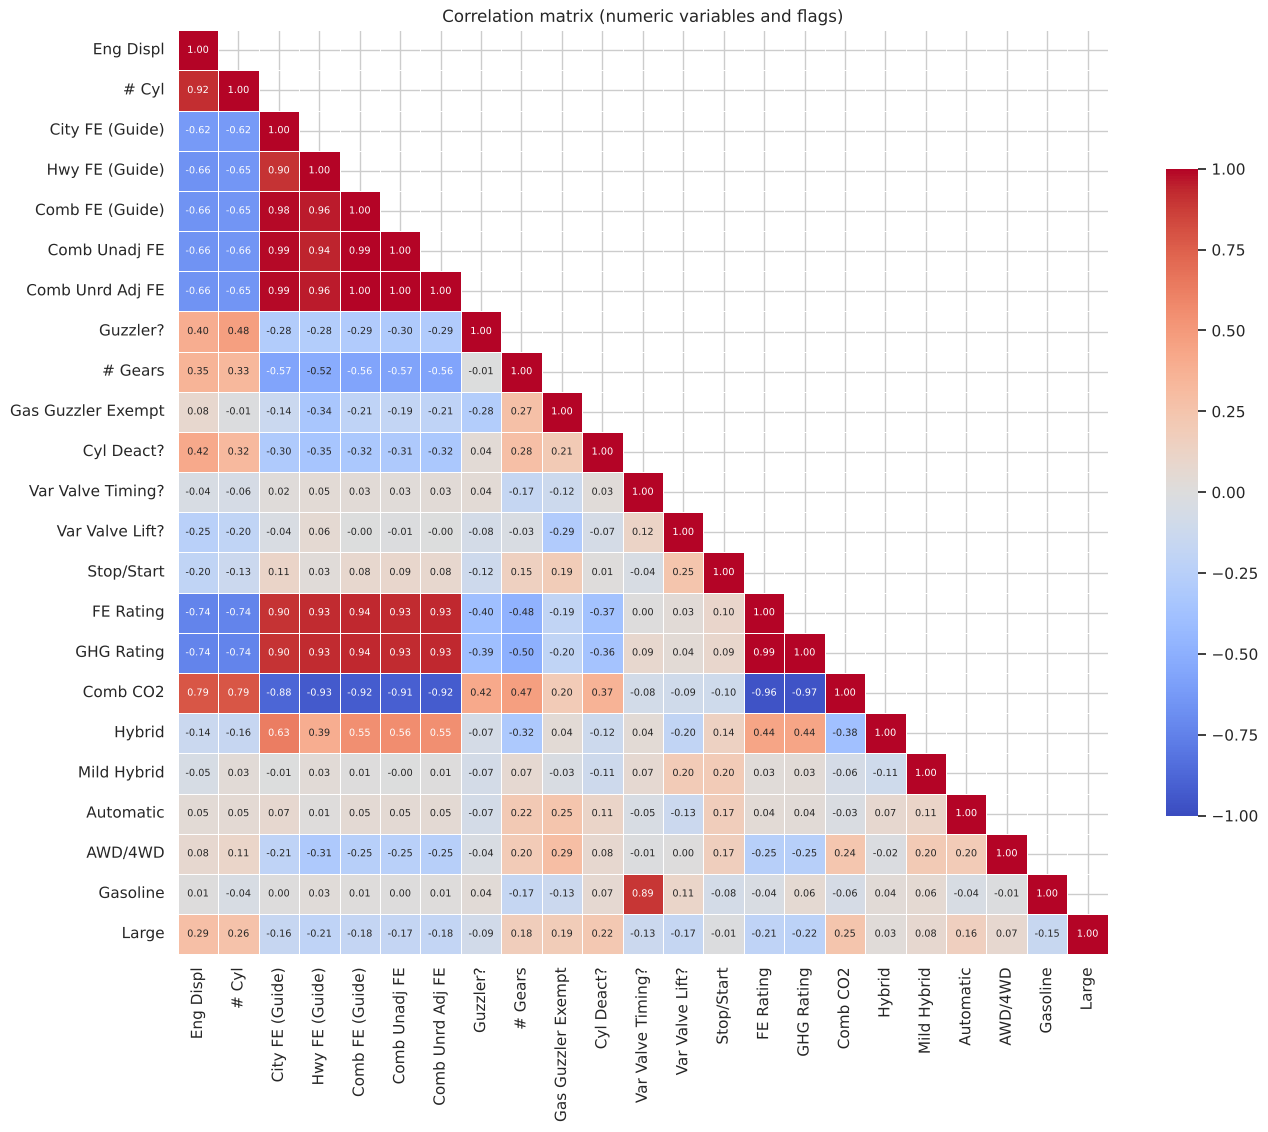

In [11]:
from vehicle_emissions.evaluation import plot_correlation, top_correlations

num = df.select_dtypes("number").astype(float)
corr = plot_correlation(num, title="Correlation matrix (numeric variables and flags)",
                        figsize=(15, 12), save_as="01_correlation_full.png")
plt.show()

In [12]:
top_correlations(corr, n=10)

,Most positive,Most negative
0,Comb FE (Guide) ↔ Comb Unrd Adj FE: 0.999,GHG Rating ↔ Comb CO2: -0.966
1,Comb Unadj FE ↔ Comb Unrd Adj FE: 0.995,FE Rating ↔ Comb CO2: -0.961
2,FE Rating ↔ GHG Rating: 0.995,Hwy FE (Guide) ↔ Comb CO2: -0.934
3,Comb FE (Guide) ↔ Comb Unadj FE: 0.994,Comb Unrd Adj FE ↔ Comb CO2: -0.925
4,City FE (Guide) ↔ Comb Unadj FE: 0.989,Comb FE (Guide) ↔ Comb CO2: -0.924
5,City FE (Guide) ↔ Comb Unrd Adj FE: 0.986,Comb Unadj FE ↔ Comb CO2: -0.914
6,City FE (Guide) ↔ Comb FE (Guide): 0.985,City FE (Guide) ↔ Comb CO2: -0.881
7,Hwy FE (Guide) ↔ Comb FE (Guide): 0.960,Eng Displ ↔ FE Rating: -0.741
8,Hwy FE (Guide) ↔ Comb Unrd Adj FE: 0.959,# Cyl ↔ GHG Rating: -0.740
9,Hwy FE (Guide) ↔ Comb Unadj FE: 0.942,Eng Displ ↔ GHG Rating: -0.739


**Leakage control.** The derived fuel economy variables (city, highway, unadjusted, label ratings, CO₂, gas guzzler)
are computed from fuel economy itself and correlate with it above 0.9. They are **excluded as predictors**: models only
use technical attributes known before the test.

In [13]:
DERIVED = ["Comb Unrd Adj FE", "Comb Unadj FE", "City FE (Guide)", "Hwy FE (Guide)", "GHG Rating",
           "FE Rating", "Comb CO2", "Guzzler?"]
r = corr["Comb FE (Guide)"].drop("Comb FE (Guide)")
pd.DataFrame({"r with Comb FE": r.round(3),
              "Use": np.where(r.index.isin(DERIVED), "excluded (derived from target)", "candidate")}
             ).sort_values("r with Comb FE", key=abs, ascending=False)

,r with Comb FE,Use
Comb Unrd Adj FE,0.999,excluded (derived from target)
Comb Unadj FE,0.994,excluded (derived from target)
City FE (Guide),0.985,excluded (derived from target)
Hwy FE (Guide),0.960,excluded (derived from target)
GHG Rating,0.935,excluded (derived from target)
FE Rating,0.935,excluded (derived from target)
Comb CO2,-0.924,excluded (derived from target)
Eng Displ,-0.660,candidate
# Cyl,-0.655,candidate
# Gears,-0.563,candidate


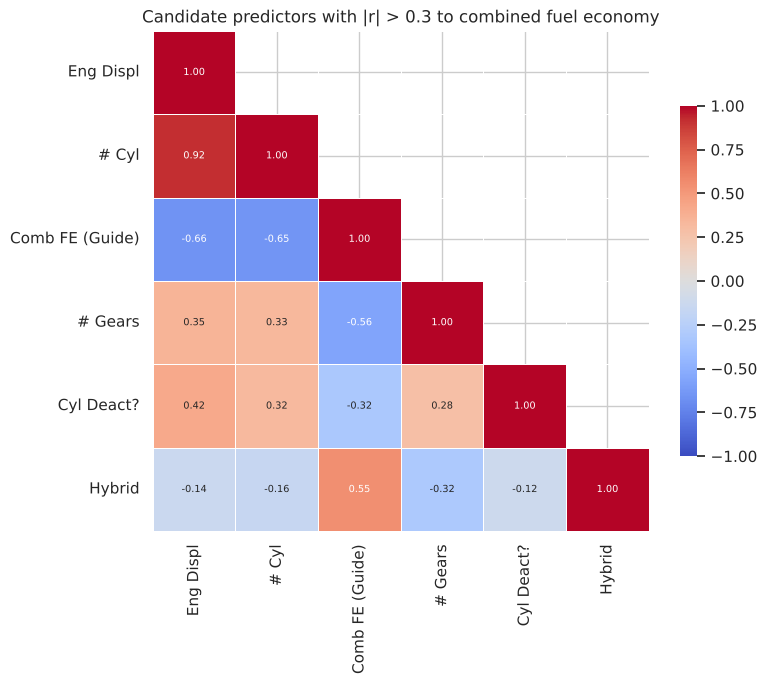

In [14]:
sel = [c for c in corr.index[corr["Comb FE (Guide)"].abs() > 0.3] if c not in DERIVED or c == "Comb FE (Guide)"]
plot_correlation(num[sel], title="Candidate predictors with |r| > 0.3 to combined fuel economy",
                 figsize=(8, 6.5), save_as="01_correlation_predictors.png")
plt.show()

`Eng Displ` and `# Cyl` are highly correlated with each other (r ≈ 0.92). For linear models this makes coefficient
interpretation harder, although it does not hurt predictive power; for tree-based models it is irrelevant.

### 4.4 Shape of the relationship with the target

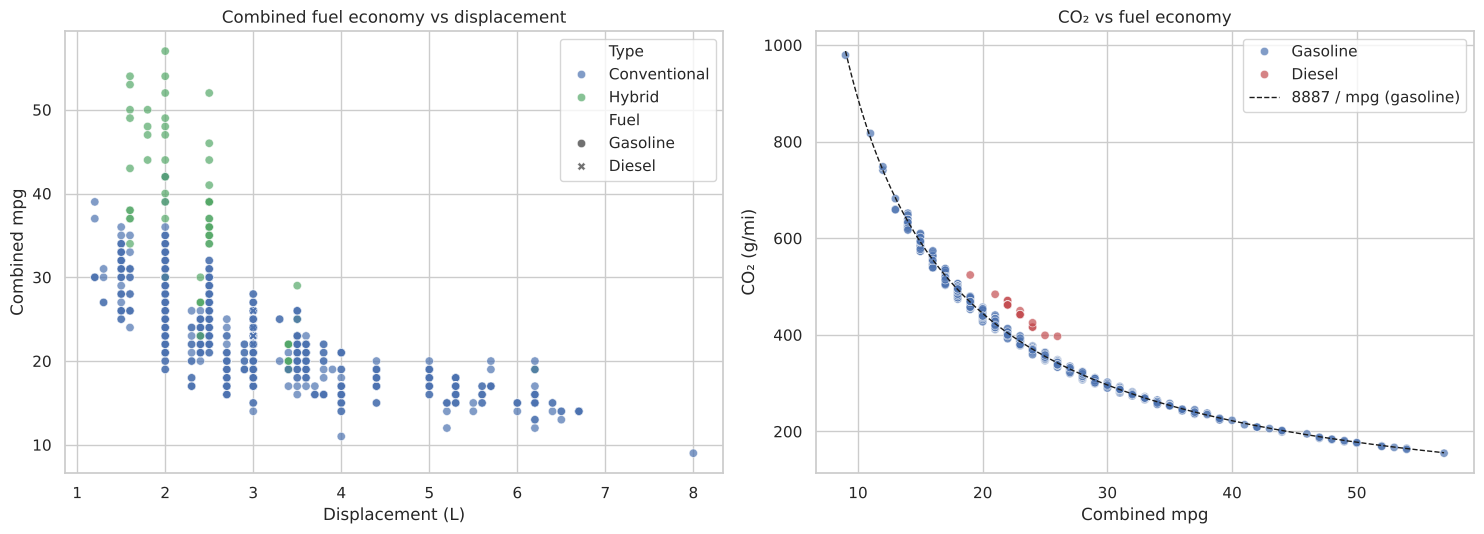

In [15]:
plot_df = df.assign(Type=df["Hybrid"].map({0: "Conventional", 1: "Hybrid"}),
                   Fuel=df["Gasoline"].map({0: "Diesel", 1: "Gasoline"}))
fig, axs = plt.subplots(1, 2, figsize=(15, 5.5))
sns.scatterplot(data=plot_df, x="Eng Displ", y="Comb FE (Guide)", hue="Type", style="Fuel",
                palette={"Conventional": "#4C72B0", "Hybrid": "#55A868"}, alpha=0.7, ax=axs[0])
axs[0].set(title="Combined fuel economy vs displacement", xlabel="Displacement (L)", ylabel="Combined mpg")
sns.scatterplot(data=plot_df, x="Comb FE (Guide)", y="Comb CO2", hue="Fuel",
                palette={"Diesel": "#C44E52", "Gasoline": "#4C72B0"}, alpha=0.7, ax=axs[1])
x = np.linspace(df["Comb FE (Guide)"].min(), df["Comb FE (Guide)"].max(), 200)
axs[1].plot(x, 8887 / x, "k--", lw=1, label="8887 / mpg (gasoline)")
axs[1].set(title="CO₂ vs fuel economy", xlabel="Combined mpg", ylabel="CO₂ (g/mi)")
axs[1].legend()
fig.tight_layout()
fig.savefig("../reports/figures/01_displacement_fuel_economy_co2.png", dpi=150, bbox_inches="tight")
plt.show()

* The displacement → mpg relationship is **non-linear and heteroscedastic**: at equal displacement, hybrids separate
  clearly. Non-linear models and the `Hybrid` flag are expected to be decisive.
* CO₂ and mpg follow an exact hyperbola (diesels sit above it because of their higher carbon content per gallon).
  A linear model should fit CO₂ (proportional to fuel per distance) better than mpg.

### 4.5 Leakage risk across variants of the same model

In [16]:
fam = df["Model Family"].value_counts()
print(f"{len(fam)} families · {(fam > 1).sum()} with several configurations · "
      f"{fam[fam > 1].sum()} rows ({fam[fam > 1].sum() / len(df):.0%}) belong to repeated families")
fam.head(8).to_frame("n configurations")

596 families · 219 with several configurations · 587 rows (61%) belong to repeated families


,n configurations
Model Family,
CHEVROLET | SILVERADO,16
GMC | SIERRA,15
TOYOTA | TUNDRA,11
CHEVROLET | SILVERADO MUD TERRAIN TIRES,9
HONDA | CIVIC 5DR,7
GMC | SIERRA MUD TERRAIN TIRES,7
CHEVROLET | TAHOE,7
CHEVROLET | CAMARO,6


Many configurations are near-identical variants of the same model. With a random split, the model may "see" the twin
variant of a test vehicle during training. Therefore, in addition to random cross-validation, the modeling notebooks
report a **cross-validation grouped by model family** (`GroupKFold`), which estimates performance on unseen vehicle
models.

## 5. Export

In [17]:
out = PROCESSED_DIR / "fe_guide_2024_clean.csv"
df.to_csv(out, index=False)
print(f"Saved data/processed/{out.name}: {df.shape[0]} rows × {df.shape[1]} columns (validated)")

Saved data/processed/fe_guide_2024_clean.csv: 964 rows × 32 columns (validated)
